<a href="https://colab.research.google.com/github/ZMvega/Estructuras_de_datos_y_laboratorio/blob/main/Laboratorio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import struct
import numpy as np
import zlib
import json

#matriz
N_FILAS = 100_000
N_COLS = 100_000
DTYPE = np.int32
TAM_ELEMENTO = np.dtype(DTYPE).itemsize
RUTA_ARCHIVO = "matriz.bin"
FILAS_POR_BLOQUE = 2_000

def escribir_matriz_memmap(ruta, n_filas, n_cols, dtype=DTYPE,
                            filas_por_bloque=FILAS_POR_BLOQUE):
    mm = np.memmap(ruta, dtype=dtype, mode="w+", shape=(n_filas, n_cols))
    for inicio_fila in range(0, n_filas, filas_por_bloque):
        fin_fila = min(inicio_fila + filas_por_bloque, n_filas)
        bloque = np.fromfunction(
            lambda i, j: (inicio_fila + i) + j,
            (fin_fila - inicio_fila, n_cols),
            dtype=dtype,
        )
        mm[inicio_fila:fin_fila, :] = bloque
    mm.flush()
    del mm
    print(f"Archivo escrito: {ruta}")

def escribir_matriz_memmap(ruta, n_filas, n_cols, dtype=DTYPE,
                            filas_por_bloque=FILAS_POR_BLOQUE):
    mm = np.memmap(ruta, dtype=dtype, mode="w+", shape=(n_filas, n_cols))
    for inicio_fila in range(0, n_filas, filas_por_bloque):
        fin_fila = min(inicio_fila + filas_por_bloque, n_filas)
        bloque = np.fromfunction(
            lambda i, j: (inicio_fila + i) + j,
            (fin_fila - inicio_fila, n_cols),
            dtype=dtype,
        )
        mm[inicio_fila:fin_fila, :] = bloque
    mm.flush()
    del mm
    print(f"Archivo escrito: {ruta}")


def mostrar_matriz_memmap(ruta, n_filas, n_cols, dtype=DTYPE,
                           alto=5, ancho=5):
    tam_total_esperado = n_filas * n_cols * np.dtype(dtype).itemsize
    tam_real = os.path.getsize(ruta)
    print(f"Tamano del archivo en disco: {tam_real / (1024**3):.2f} GB "
          f"(esperado: {tam_total_esperado / (1024**3):.2f} GB)")

    mm = np.memmap(ruta, dtype=dtype, mode="r", shape=(n_filas, n_cols))
    print("Esquina superior izquierda:")
    print(mm[:alto, :ancho])

    fila_prueba, col_prueba = n_filas - 1, n_cols - 1
    print(f"Celda ({fila_prueba}, {col_prueba}) = {mm[fila_prueba, col_prueba]}")
    del mm
#cierra el mapeo no descarga nada solo libera el objeto


RUTA_DATOS_COMPRIMIDOS = "matriz_comprimida.bin"
RUTA_INDICE = "matriz_indice.json"


def escribir_matriz_comprimida(ruta_datos, ruta_indice, n_filas, n_cols,
                                dtype=DTYPE, filas_por_bloque=FILAS_POR_BLOQUE):
    indice = []  # un registro por bloque: offset y tamano comprimido
    with open(ruta_datos, "wb") as f:
        offset_actual = 0
        for inicio_fila in range(0, n_filas, filas_por_bloque):
            fin_fila = min(inicio_fila + filas_por_bloque, n_filas)
            bloque = np.fromfunction(
                lambda i, j: (inicio_fila + i) + j,
                (fin_fila - inicio_fila, n_cols),
                dtype=dtype,
            )
            crudo = bloque.tobytes()
            comprimido = zlib.compress(crudo, level=6)

            f.write(comprimido)
            indice.append({
                "fila_inicio": inicio_fila,
                "fila_fin": fin_fila,
                "offset": offset_actual,
                "tam_comprimido": len(comprimido),
            })
            offset_actual += len(comprimido)

    with open(ruta_indice, "w") as f:
        json.dump(indice, f)

    tam_comprimido_total = os.path.getsize(ruta_datos)
    tam_sin_comprimir = n_filas * n_cols * np.dtype(dtype).itemsize
    print(f"Tamano sin comprimir: {tam_sin_comprimir / (1024**3):.2f} GB")
    print(f"Tamano comprimido:    {tam_comprimido_total / (1024**3):.2f} GB")


def leer_celda_comprimida(ruta_datos, ruta_indice, i, j, n_cols, dtype=DTYPE):
    tam_elem = np.dtype(dtype).itemsize
    with open(ruta_indice) as f:
        indice = json.load(f)

    entrada = next(b for b in indice if b["fila_inicio"] <= i < b["fila_fin"])

    with open(ruta_datos, "rb") as f:
        f.seek(entrada["offset"])
        comprimido = f.read(entrada["tam_comprimido"])

    crudo = zlib.decompress(comprimido)
    n_cols_bloque = n_cols
    fila_local = i - entrada["fila_inicio"]
    bloque = np.frombuffer(crudo, dtype=dtype).reshape(-1, n_cols_bloque)
    return bloque[fila_local, j]

def mostrar_matriz_comprimida(ruta_datos, ruta_indice, n_filas, n_cols, dtype=DTYPE,
                               alto=5, ancho=5):
    tam_comprimido = os.path.getsize(ruta_datos)
    tam_sin_comprimir = n_filas * n_cols * np.dtype(dtype).itemsize
    print(f"Tamano comprimido: {tam_comprimido / (1024**2):.2f} MB "
          f"(sin comprimir: {tam_sin_comprimir / (1024**2):.2f} MB)")

    for i in range(alto):
        fila = [leer_celda_comprimida(ruta_datos, ruta_indice, i, j, n_cols, dtype)
                for j in range(ancho)]
        print(fila)



if __name__ == "__main__":
    #borrar y limpiar
    for viejo in [RUTA_ARCHIVO, RUTA_DATOS_COMPRIMIDOS, RUTA_INDICE]:
        if os.path.exists(viejo):
            os.remove(viejo)

    #memmap
    escribir_matriz_memmap(RUTA_ARCHIVO, N_FILAS, N_COLS)
    mostrar_matriz_memmap(RUTA_ARCHIVO, N_FILAS, N_COLS)

    #comprimido
    escribir_matriz_comprimida(RUTA_DATOS_COMPRIMIDOS, RUTA_INDICE, N_FILAS, N_COLS)
    mostrar_matriz_comprimida(RUTA_DATOS_COMPRIMIDOS, RUTA_INDICE, N_FILAS, N_COLS)

Archivo escrito: matriz.bin
Tamano del archivo en disco: 37.25 GB (esperado: 37.25 GB)
Esquina superior izquierda:
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]
 [4 5 6 7 8]]
Celda (99999, 99999) = 199998


image.png

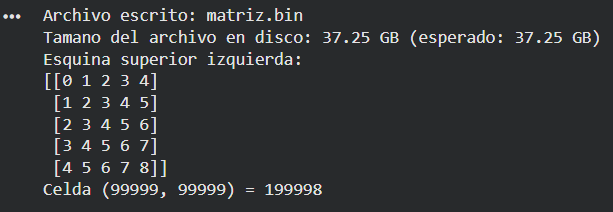